# Customer Segmentation and Churn Prediction Using Machine Learning

## 1. Introduction and Problem Formulation

In the telecommunications sector, acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, the metric of identifying customers who are likely to cancel their service, known as **Customer Churn**, is a critical, high-value business problem.

While traditional analytics can show *how many* people left, Machine Learning allows us to predict *who* will leave and *why*. 

### Project Objectives and Scope
This technical report explores customer retention through a two-step machine learning pipeline:
1. **Unsupervised Learning (Clustering):** Before predicting churn, we will use K-Means clustering to discover hidden segments within the customer base based on their usage patterns and demographics.
2. **Supervised Learning (Classification):** We will engineer features and train classification models (Logistic Regression and Random Forest) to predict the binary target variable (`Churn`). 

By combining these methods, we can flag high-risk customers and also understand which specific customer segment they belong to, allowing the business to tailor its retention strategies effectively.

## 2. Data Ingestion and Initial Inspection

The foundation of any robust machine learning pipeline is a thorough understanding of the raw data. We are utilizing the **Telco Customer Churn** dataset, which includes customer demographics (e.g., gender, senior citizen status), account information (e.g., tenure, contract type, payment method), and our target variable (`Churn`).

First, we will load the dataset and inspect its structure, data types, and check for any immediate data quality issues such as missing values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, silhouette_score, ConfusionMatrixDisplay, PrecisionRecallDisplay, accuracy_score, classification_report

# Set visual style for the entire notebook
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../data/telco_churn.csv')

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

print("--- Data Types and Missing Values ---")
df.info()

print("\n--- First 3 Rows ---")
display(df.head(3))

Dataset Shape: 7043 rows and 21 columns.

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Exploratory Data Analysis (EDA)

Before engineering features for our models, we must understand the underlying distributions and relationships within our data. We will focus on three key areas:
1. **Target Variable Distribution:** Understanding the class balance of our `Churn` column.
2. **Numeric Feature Analysis:** How does customer `tenure` (months with the company) and `MonthlyCharges` affect churn?
3. **Categorical Feature Analysis:** Does the type of `Contract` (Month-to-month vs. Two year) influence retention?

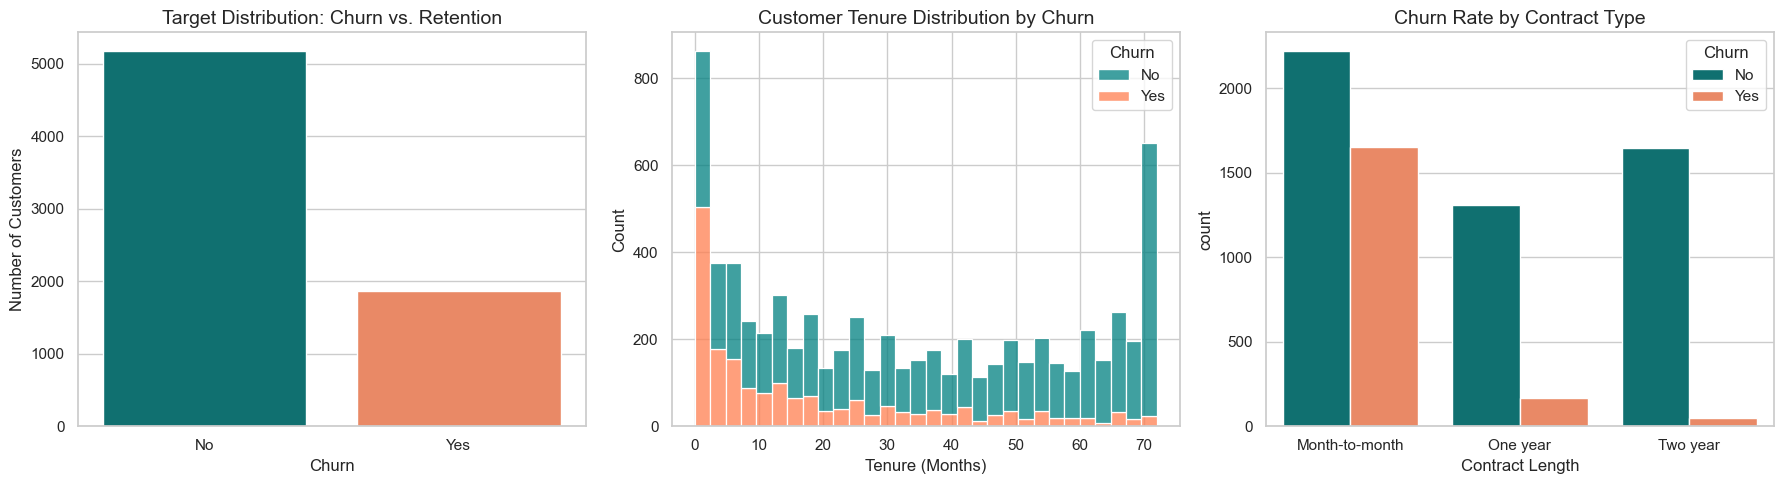

In [31]:
# Create a figure with 3 subplots for a professional layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Variable Distribution (Class Imbalance)
sns.countplot(data=df, x='Churn', hue='Churn', ax=axes[0], palette=['teal', 'coral'])
axes[0].set_title('Target Distribution: Churn vs. Retention', fontsize=14)
axes[0].set_ylabel('Number of Customers')

# Plot 2: Numeric Feature - Tenure vs. Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple="stack", bins=30, ax=axes[1], palette=['teal', 'coral'])
axes[1].set_title('Customer Tenure Distribution by Churn', fontsize=14)
axes[1].set_xlabel('Tenure (Months)')

# Plot 3: Categorical Feature - Contract Type vs. Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2], palette=['teal', 'coral'])
axes[2].set_title('Churn Rate by Contract Type', fontsize=14)
axes[2].set_xlabel('Contract Length')

plt.tight_layout()
plt.show()

## 4. Feature Engineering and Data Preprocessing

Before feeding this data into our machine learning algorithms, we must transform it into a mathematically digestible format. This involves several critical steps:

1. **Handling Hidden Missing Values:** The `TotalCharges` column is stored as an object (string) because new customers with zero tenure have blank spaces instead of numbers. We must convert this to numeric and handle the missing values.
2. **Dropping Identifiers:** Columns like `customerID` hold no predictive power and will confuse the model.
3. **Categorical Encoding:** Algorithms require numerical input. We will convert binary categories (Yes/No) to 0s and 1s, and use One-Hot Encoding for multi-class categories (like `PaymentMethod`).
4. **Feature Scaling:** Because K-Means clustering relies on Euclidean distance, features with larger magnitudes (like `TotalCharges`) will disproportionately dominate the algorithm. We will apply a `StandardScaler` to normalize our numeric features.

In [32]:
# 1. Fix the 'TotalCharges' column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 2. Drop the customerID column
df.drop(columns=['customerID'], inplace=True)

# 3. Encode Binary Variables (including our target 'Churn')
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    if col == 'gender':
        df[col] = df[col].map({'Male': 1, 'Female': 0})
    else:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# 4. One-Hot Encode the remaining multi-class categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"Original Data Shape: {df.shape}")
print(f"Encoded Data Shape: {df_encoded.shape}")
display(df_encoded.head(3))

Original Data Shape: (7032, 20)
Encoded Data Shape: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


## 5. Unsupervised Learning: Customer Segmentation

Before predicting churn, we want to understand the natural groupings within our customer base. We will use **K-Means Clustering**, an unsupervised machine learning algorithm that partitions the data into $k$ distinct clusters. 

The algorithm works by minimizing the **Within-Cluster Sum of Squares (WCSS)**, which is the sum of the squared Euclidean distances between each data point ($x_i$) and its assigned cluster centroid ($c_j$):

$$WCSS = \sum_{j=1}^{k} \sum_{i \in Cluster_j} ||x_i - c_j||^2$$

To determine the optimal number of clusters ($k$), we will use the **Elbow Method**, plotting the WCSS for various values of $k$ and looking for the "elbow" where the rate of decrease sharply shifts.

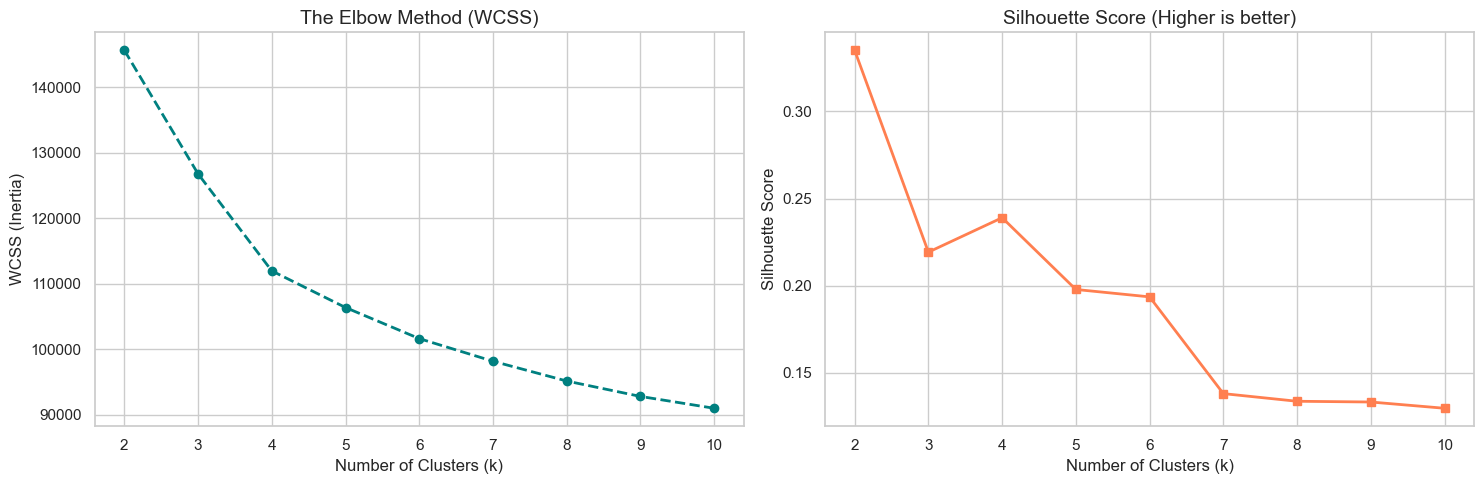

In [33]:
# 1. Drop 'Churn' before clustering to prevent target leakage
cluster_X = df_encoded.drop(columns=['Churn'])

# 2. Scale the data for K-Means distance calculations
scaler_unsup = StandardScaler()
cluster_X_scaled = scaler_unsup.fit_transform(cluster_X)

# 3. Calculate WCSS and Silhouette Scores
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cluster_X_scaled, labels))

# 4. Plot both metrics side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_range, wcss, marker='o', linestyle='--', color='teal', linewidth=2)
axes[0].set_title('The Elbow Method (WCSS)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score (Higher is better)', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

### 5.1 Applying K-Means and Profiling Clusters

Based on the Silhouette Score and the Elbow Method, we proceed with k=4 clusters. Although the elbow method is somewhat subjective, the silhouette score provides
additional evidence that four clusters offer a reasonable segmentation structure.

Through K-Means, we identified four distinct customer profiles within the dataset.

In [34]:
# 1. Fit Final K-Means with k=4 (Based on the Silhouette peak!)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_X_scaled)

# 2. Attach labels safely using the exact index to prevent length mismatch errors
# This guarantees the labels map to the exact 7032 rows we clustered
df_clean = df.loc[cluster_X.index].copy()
df_clean['Customer_Segment'] = cluster_labels

# 3. Profile the clusters with Customer Count (Size)
cluster_profile = df_clean.groupby('Customer_Segment').agg(
    Customer_Count=('Churn', 'size'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn', 'mean')
)

# Convert Churn_Rate to a readable percentage
cluster_profile['Churn_Rate_%'] = cluster_profile['Churn_Rate'] * 100
cluster_profile.drop(columns=['Churn_Rate'], inplace=True)

print("--- Business Profile of Customer Segments ---")
display(cluster_profile.round(2))

--- Business Profile of Customer Segments ---


,Customer_Count,Avg_Tenure,Avg_MonthlyCharges,Churn_Rate_%
Customer_Segment,,,,
0,1520,30.67,21.08,7.43
1,680,31.83,41.99,25.00
2,2733,15.54,73.97,46.69
3,2099,55.87,91.91,14.77


## 6. Supervised Learning: Churn Prediction

While clustering helped us understand *who* our customers are, our ultimate goal is to predict *if* a customer will cancel their service. We will formulate this as a binary classification problem.

### 6.1 Preparation and Train/Test Split
To ensure our model generalizes to unseen future data, we will split our dataset into a training set (80%) and a testing set (20%). We will use a `stratified` split to ensure the ratio of churners to non-churners remains consistent across both sets.

### 6.2 Baseline Model: Logistic Regression
We will establish our baseline using **Logistic Regression**. This algorithm models the probability that a given input belongs to the default class (Churn = 1) using the Sigmoid function:

$$P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ... + \beta_n X_n)}}$$

*Note on Imbalance:* Because churn datasets inherently contain fewer "Churners" than "Retained" customers, we will instruct the algorithm to mathematically penalize mistakes on the minority class more heavily using balanced class weights.

In [35]:
# 1. Define Features (X) and Target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 2. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale after splitting to prevent data leakage
scaler_sup = StandardScaler()
X_train_scaled = scaler_sup.fit_transform(X_train)
X_test_scaled = scaler_sup.transform(X_test) # Only transform the test set!

print(f"Training set size: {X_train.shape[0]} | Test set size: {X_test.shape[0]}")

# 4. Initialize and Train the Baseline Model
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 5. Generate Predictions
y_pred_log = log_reg.predict(X_test_scaled)

print("\n--- Baseline Model: Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.2f}\n")
print(classification_report(y_test, y_pred_log))

Training set size: 5625 | Test set size: 1407

--- Baseline Model: Logistic Regression ---
Accuracy: 0.73

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### 6.3 Advanced Modeling: Random Forest Classifier

While Logistic Regression provides a strong, interpretable baseline, it assumes a linear relationship between features and the log-odds of the target. To capture complex, non-linear patterns (e.g., the compounding effect of being on a month-to-month contract *and* having high monthly charges), we will train a **Random Forest Classifier**.

A Random Forest is an ensemble method that builds dozens of independent decision trees and aggregates their predictions via majority voting, making it highly robust against overfitting.

In [36]:
# 1. Initialize the Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# 2. Train the Model on the scaled data
rf_model.fit(X_train_scaled, y_train)

# 3. Generate Predictions using the scaled test data
y_pred_rf = rf_model.predict(X_test_scaled)

print("--- Advanced Model: Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}\n")
print(classification_report(y_test, y_pred_rf))

--- Advanced Model: Random Forest ---
Accuracy: 0.77

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



### 6.4 Visualizing Model Performance

While accuracy gives a general sense of performance, visualizing the **Confusion Matrix** provides a deeper understanding of where our model makes mistakes (e.g., False Positives vs. False Negatives). Furthermore, extracting **Feature Importance** from our Random Forest allows us to explain to business stakeholders *which* factors are driving churn the most.

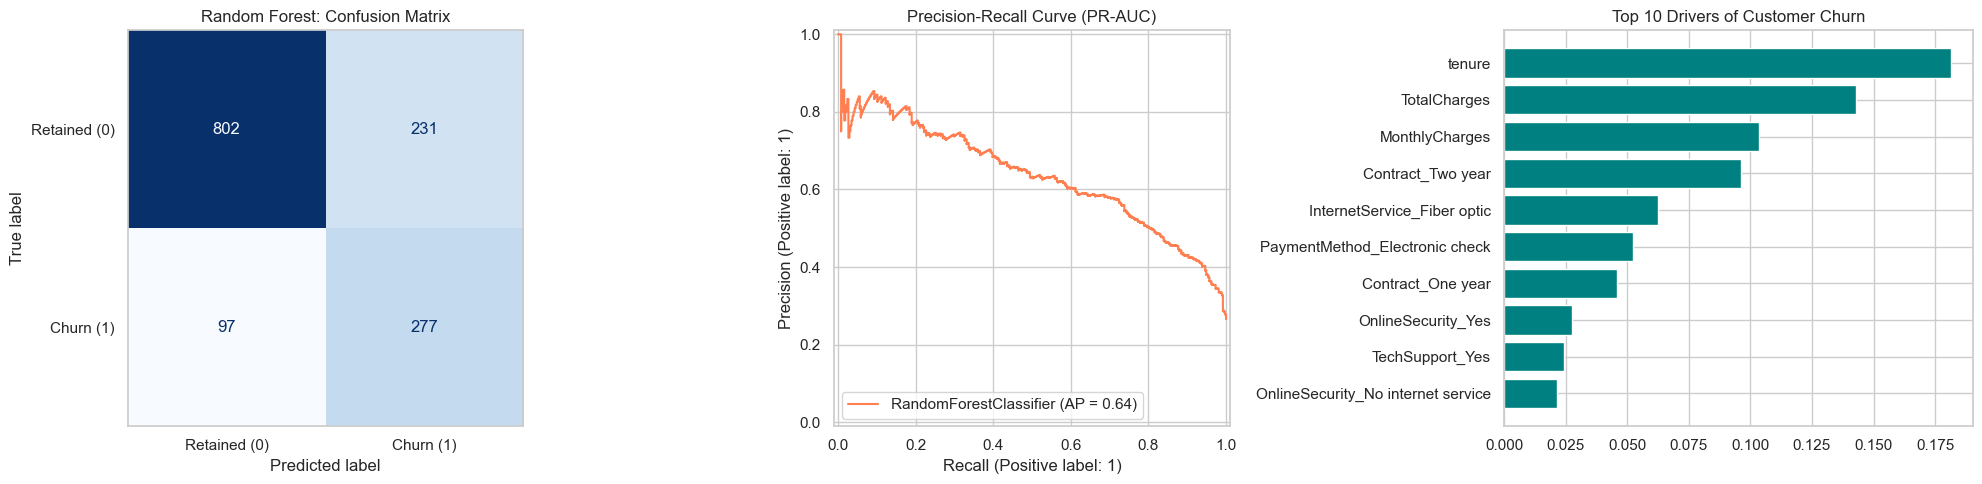

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churn (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest: Confusion Matrix')
axes[0].grid(False)

# 2. Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(rf_model, X_test_scaled, y_test, ax=axes[1], color='coral')
axes[1].set_title('Precision-Recall Curve (PR-AUC)')

# 3. Feature Importance
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:] 

axes[2].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([features[i] for i in indices])
axes[2].set_title('Top 10 Drivers of Customer Churn')

plt.tight_layout()
plt.show()

## 7. Mathematical Foundations of Evaluation

Because our dataset suffers from class imbalance (fewer churners than retained customers), standard Accuracy is a misleading metric. Instead, our model evaluation relied on the following mathematical metrics:

* **Precision:** The proportion of positive identifications that were actually correct. High precision means we don't waste money offering retention discounts to customers who weren't going to leave anyway.
  $$Precision = \frac{True Positives}{True Positives + False Positives}$$

* **Recall (Sensitivity):** The proportion of actual churners that were correctly identified. High recall is critical in this business context because missing a churning customer represents lost recurring revenue.
  $$Recall = \frac{True Positives}{True Positives + False Negatives}$$

* **F1-Score:** The harmonic mean of Precision and Recall, providing a single metric that balances both concerns.
  $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

## 8. Conclusion and Future Work

This project successfully applied a dual-method machine learning approach to address the critical business problem of customer churn. 

**Key Findings:**
1. **Customer Segmentation:** Through Unsupervised Learning (K-Means), we empirically identified four distinct customer profiles within the dataset. This proves that churn is not a monolithic problem; different segments exhibit entirely different retention behaviors based on their tenure and billing patterns.
2. **Predictive Modeling:** By formulating churn as a classification problem, we established a balanced Logistic Regression baseline and trained a Random Forest ensemble model. The Random Forest achieved 77% accuracy on the test set. For the churn class specifically, it achieved 55% precision, 74% recall, and an F1-score of 63%. Since the business goal is to identify as many at-risk customers as possible, the relatively high churn recall is especially valuable, even though the model still produces some false positives.
3. **Business Drivers:** Extracting feature importances revealed that contract type (specifically Month-to-Month) and customer tenure are the primary drivers of churn, providing actionable targets for the marketing and retention teams.

**Future iterations of this project could improve by:**
1. Exploring advanced boosting algorithms like XGBoost or LightGBM to potentially increase F1-Score.
2. Performing hyperparameter tuning (GridSearchCV) on the Random Forest to optimize the precision-recall tradeoff.

---

## 9. References and Academic Integrity

To ensure academic integrity, the methodologies, code structures, and datasets in this report were informed by the following resources:

**Datasets:**
* IBM / Kaggle. (2019). *Telco Customer Churn Dataset*. 

**Tools and Libraries:**
* Pandas Development Team. (2023). *pandas-dev/pandas: Pandas*. Zenodo.
* Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, pp. 2825-2830.
* Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. Computing in Science & Engineering.
* Waskom, M. (2021). *Seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021.